In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/MachineLearningCSV"

import os
print("Files found:", os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found: ['Tuesday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']


In [ ]:
import glob, gc, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
OUTPUT_DIR = "hybrid_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files containing attack types the model IS allowed to train on
KNOWN_FILES = [
    "Monday-WorkingHours_pcap_ISCX.csv",                        # BENIGN only
    "Tuesday-WorkingHours_pcap_ISCX.csv",                        # + Brute Force
    "Wednesday-workingHours_pcap_ISCX.csv",                      # + DoS variants
    "Friday-WorkingHours-Afternoon-DDos_pcap_ISCX.csv",          # + DDoS
    "Friday-WorkingHours-Afternoon-PortScan_pcap_ISCX.csv",      # + PortScan
]

# Files held out entirely from training -- simulate zero-day attacks
ZERODAY_FILES = [
    "Thursday-WorkingHours-Morning-WebAttacks_pcap_ISCX.csv",       # Web Attacks
    "Thursday-WorkingHours-Afternoon-Infilteration_pcap_ISCX.csv",  # Infiltration
    "Friday-WorkingHours-Morning_pcap_ISCX.csv",                    # Bot
]

In [ ]:
DATA_DIR = "/content/drive/MyDrive/MachineLearningCSV"

def load_cicids2017(data_dir):
    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")
    print(f"Found {len(csv_files)} CSV file(s). Loading...")
    frames = []
    for f in csv_files:
        print(f"  - {os.path.basename(f)}")
        frames.append(pd.read_csv(f, low_memory=False, encoding="latin1"))
    data = pd.concat(frames, ignore_index=True)
    data.columns = [c.strip() for c in data.columns]
    print(f"Combined dataset shape: {data.shape}")
    return data


def generate_demo_data(n_samples=20000, n_features=30, random_state=RANDOM_STATE):
    from sklearn.datasets import make_classification
    feature_names = [
        "Destination Port", "Flow Duration", "Total Fwd Packets",
        "Total Backward Packets", "Total Length of Fwd Packets",
        "Total Length of Bwd Packets", "Fwd Packet Length Max",
        "Fwd Packet Length Min", "Fwd Packet Length Mean",
        "Bwd Packet Length Max", "Bwd Packet Length Min",
        "Bwd Packet Length Mean", "Flow Bytes/s", "Flow Packets/s",
        "Flow IAT Mean", "Flow IAT Std", "Fwd IAT Mean", "Bwd IAT Mean",
        "Fwd PSH Flags", "Bwd PSH Flags", "SYN Flag Count",
        "ACK Flag Count", "URG Flag Count", "Down/Up Ratio",
        "Average Packet Size", "Subflow Fwd Bytes", "Subflow Bwd Bytes",
        "Init_Win_bytes_forward", "Init_Win_bytes_backward", "Active Mean",
    ][:n_features]
    X, y = make_classification(
        n_samples=n_samples, n_features=n_features, n_informative=18,
        n_redundant=6, n_classes=2, weights=[0.8, 0.2],
        flip_y=0.01, class_sep=1.1, random_state=random_state
    )
    df = pd.DataFrame(X, columns=feature_names)
    df = df.abs() * 1000
    df["Label"] = np.where(y == 0, "BENIGN", "DDoS")
    print(f"Generated synthetic demo dataset: {df.shape}")
    return df


# ---- CHOOSE ----
USE_DEMO = False   # using your real uploaded data from Drive

df = generate_demo_data() if USE_DEMO else load_cicids2017(DATA_DIR)

Found 8 CSV file(s). Loading...
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Combined dataset shape: (2830743, 79)


In [ ]:
def preprocess(df, label_col="Label", binary=True):
    df = df.copy()
    before = len(df)
    df.drop_duplicates(inplace=True)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    print(f"Dropped {before - len(df)} rows (duplicates/inf/NaN). Remaining: {len(df)}")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    constant_cols = [c for c in numeric_cols if df[c].nunique() <= 1]
    if constant_cols:
        df.drop(columns=constant_cols, inplace=True)
        print(f"Dropped {len(constant_cols)} constant columns")

    if binary:
        y = df[label_col].apply(lambda v: 0 if str(v).strip().upper() == "BENIGN" else 1)
        class_names = ["BENIGN", "ATTACK"]
    else:
        le = LabelEncoder()
        y = le.fit_transform(df[label_col].astype(str))
        class_names = list(le.classes_)

    X = df.drop(columns=[label_col]).select_dtypes(include=[np.number])
    print(f"Feature matrix: {X.shape}, classes: {class_names}")
    print(pd.Series(y).value_counts(normalize=True))
    return X, y, class_names

X, y, class_names = preprocess(df)

Dropped 332763 rows (duplicates/inf/NaN). Remaining: 2497980
Dropped 8 constant columns
Feature matrix: (2497980, 70), classes: ['BENIGN', 'ATTACK']
Label
0    0.829572
1    0.170428
Name: proportion, dtype: float64


In [ ]:
def select_features(X, y, k=15):
    k = min(k, X.shape[1])
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    selector.fit(X, y)
    selected_cols = X.columns[selector.get_support()]
    scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
    print(f"Top {k} features (mutual information):")
    print(scores.head(k))
    return X[selected_cols], scores

X_selected, feature_scores = select_features(X, y, k=15)

Top 15 features (mutual information):
Average Packet Size            0.354139
Packet Length Std              0.336723
Packet Length Variance         0.336669
Packet Length Mean             0.326722
Total Length of Bwd Packets    0.301465
Subflow Bwd Bytes              0.301327
Avg Bwd Segment Size           0.297016
Bwd Packet Length Mean         0.296967
Max Packet Length              0.275756
Subflow Fwd Bytes              0.271074
Total Length of Fwd Packets    0.270981
Bwd Packet Length Max          0.270056
Destination Port               0.269176
Init_Win_bytes_backward        0.264744
Init_Win_bytes_forward         0.262930
dtype: float64



Training Decision Tree...
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    518064
      ATTACK       1.00      0.99      0.99    106431

    accuracy                           1.00    624495
   macro avg       1.00      0.99      1.00    624495
weighted avg       1.00      1.00      1.00    624495



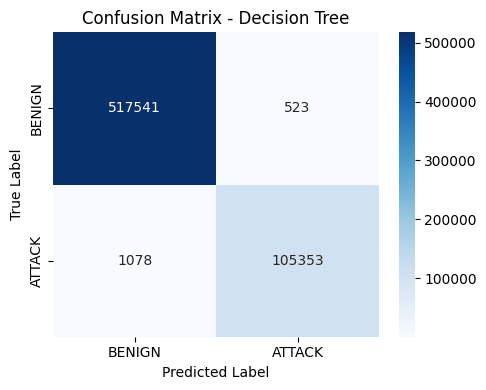


Training Random Forest...
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    518064
      ATTACK       1.00      0.99      0.99    106431

    accuracy                           1.00    624495
   macro avg       1.00      1.00      1.00    624495
weighted avg       1.00      1.00      1.00    624495



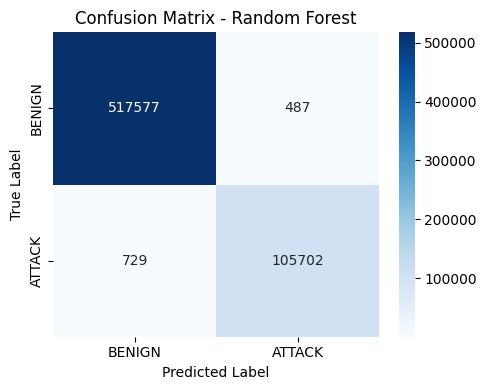


Training Gradient Boosting...
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    518064
      ATTACK       0.99      0.99      0.99    106431

    accuracy                           1.00    624495
   macro avg       1.00      0.99      0.99    624495
weighted avg       1.00      1.00      1.00    624495



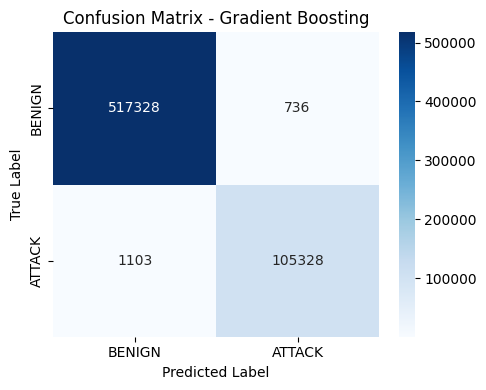


=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.998053,0.998052,0.998053,0.998052,0.999900
0,Decision Tree,0.997436,0.997434,0.997436,0.997434,0.999750
2,Gradient Boosting,0.997055,0.997052,0.997055,0.997053,0.999846


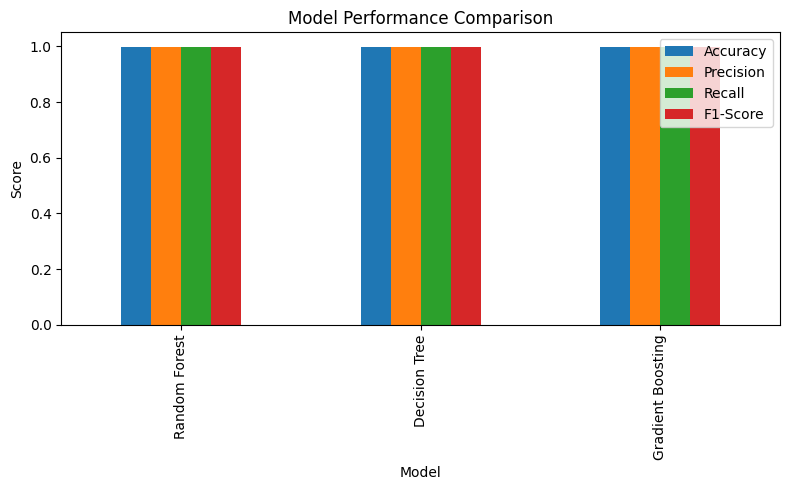


Best performing model: Random Forest


In [ ]:
def plot_confusion_matrix(y_test, y_pred, class_names, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.tight_layout(); plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=RANDOM_STATE),
}

results, fitted_models = [], {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if len(class_names) == 2 else None

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }
    if y_proba is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_proba)
    results.append(metrics)
    fitted_models[name] = model

    print(classification_report(y_test, y_pred, target_names=class_names))
    plot_confusion_matrix(y_test, y_pred, class_names, name)

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
print("\n=== Model Comparison ===")
display(results_df)

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison"); plt.ylabel("Score"); plt.ylim(0,1.05)
plt.tight_layout(); plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
print(f"\nBest performing model: {best_model_name}")

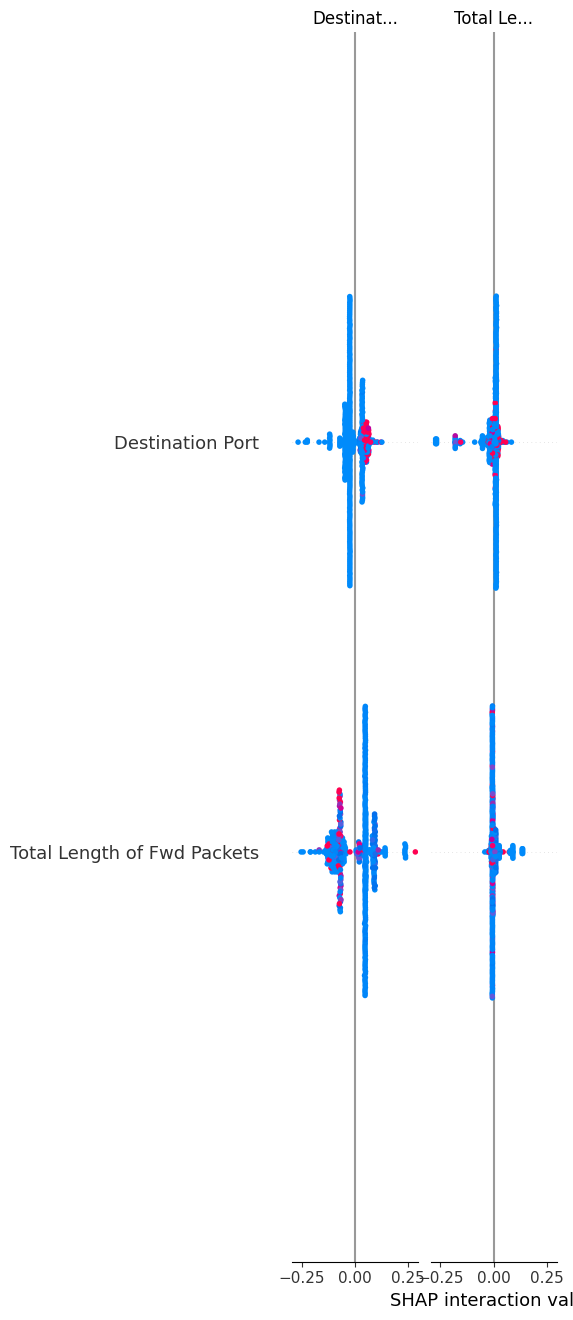

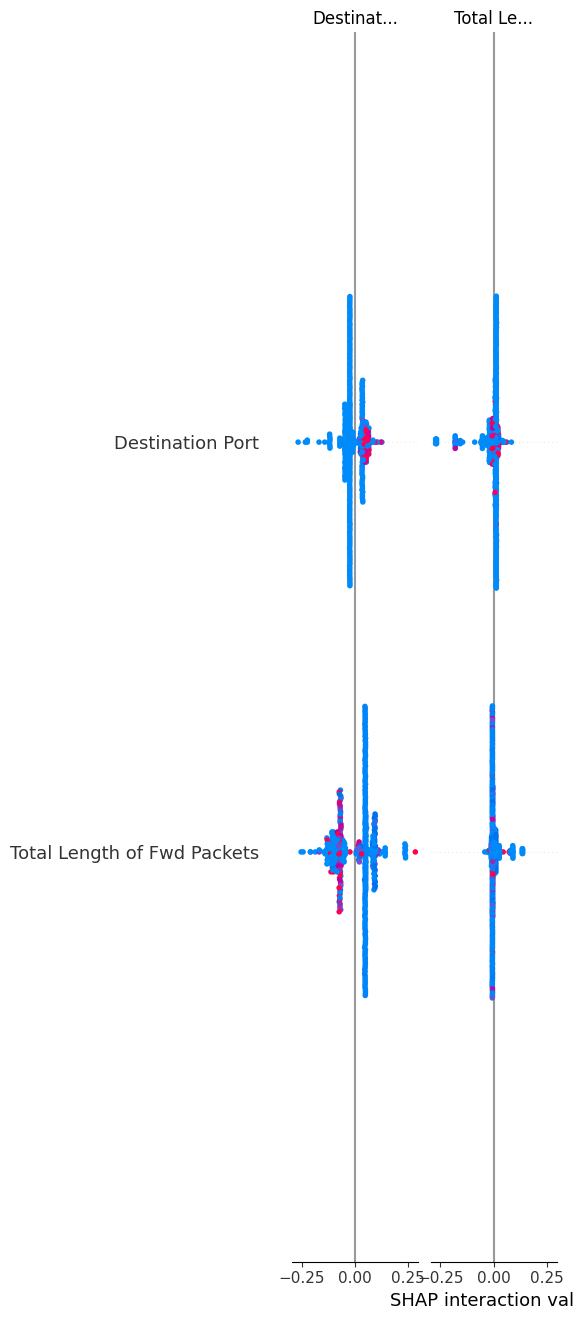

In [ ]:
import shap

X_train_df = pd.DataFrame(X_train_scaled, columns=X_selected.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_selected.columns)

explainer = shap.TreeExplainer(best_model)
sample = X_test_df.sample(min(500, len(X_test_df)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)
values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(values_to_plot, sample, max_display=15)
shap.summary_plot(values_to_plot, sample, plot_type="bar", max_display=15)